In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

/home/dnanexus/anngeno/anngeno/anngeno.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [2]:
# Configuration and paths
or_threshold_pheno = 0.99
or_threshold_anno = 0.95

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_variants_union_annotated_genocode_251103.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()

filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

# min_range = -500
# max_range = +0

anno = (
    anno
    .filter(
        (pl.col('vep_gencode_non_coding') == True) &
        # filter_expression &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0) &
        #     (pl.col('consequence_splice_region_variant') == 0) &
        #     (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
        #     (pl.col('consequence_splice_donor_region_variant') == 0) &
        #     (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        # ) &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0)
        #     (pl.col('consequence_start_retained_variant') == 0) &
        #     (pl.col('consequence_start_lost') == 0)
        # ) &
        
        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

promoterai_abs,promoterai,esmscoremissense,gene_name,delta_score,dist_to_tss,pangolin_score,loftee_hc,gpn_star_llr_calibrated_mean,region,verphylop,Strand,gpn_score,absplice_dna_max,TSS,absplice2_max,cadd_raw,gene_length,abexp_min,id,mamphylop,am_pathogenicity
f32,f32,f32,str,f32,i64,f32,i8,f64,str,f32,cat,f32,f32,i64,f32,f32,i64,f64,str,f32,f32
0.0,0.0,0.0,"""LRP2""",0.0,165367,0.0,0,0.153293,"""ENSG00000081479""",0.217,"""-""",-1.5,0.001,169362534,0.000033,0.466688,235427,-0.006063,"""chr2:169197167:T:G""",0.774,0.0
0.0,0.0,0.0,"""LRP2""",0.01,158242,0.0,0,1.684965,"""ENSG00000081479""",0.291,"""-""",-0.63,0.003,169362534,0.000116,0.104863,235427,-0.026342,"""chr2:169204292:A:T""",0.085,0.0
0.0,0.0,0.0,"""ABCB11""",0.0,793,0.0,0,-1.212965,"""ENSG00000073734""",0.023,"""-""",-1.64,0.001,169031324,0.000033,0.326902,115828,-0.005501,"""chr2:169030531:C:T""",0.015,0.0
0.0,0.0,0.0,"""ABCB11""",0.0,120499,0.0,0,-1.479978,"""ENSG00000073734""",0.341,"""-""",-4.15,0.0,169031324,0.0,0.554549,115828,-0.019354,"""chr2:168910825:T:G""",0.327,0.0
0.0,0.0,0.0,"""ABCB11""",0.0,24150,0.0,0,-0.238119,"""ENSG00000073734""",0.193,"""-""",0.08,0.001,169031324,0.000033,-0.070862,115828,-0.005501,"""chr2:169007174:C:T""",0.19,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,"""PEAR1""",0.0,-3583,0.0,0,0.364867,"""ENSG00000187800""",0.747,"""+""",-1.42,0.0,156893697,0.0,0.958715,22733,null,"""chr1:156890114:C:T""",0.732,0.0
0.0,0.0,0.0,"""GCKR""",0.0,29323,0.0,0,-0.362401,"""ENSG00000084734""",-0.276,"""+""",-1.06,0.0,27496838,0.0,-0.024889,26847,null,"""chr2:27526161:C:A""",-0.293,0.0
0.0,0.0,0.0,"""GCKR""",0.0,28041,0.0,0,0.407678,"""ENSG00000084734""",0.009,"""+""",-1.41,0.0,27496838,0.0,0.579763,26847,null,"""chr2:27524879:T:C""",-0.009,0.0


In [4]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]),
        anno_score_count = pl.len().over(["region", "annotation"])
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count')
    )
    # .filter( 
    #     pl.col('annotation_score_dircor_ptile') > or_threshold_anno
    # )

    # Filter based on category
    .filter(
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])
    )
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor,annotation_score_dircor_rank,anno_score_count,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i64,f64,f64,u64,f64
"""chr2:169197167:T:G""","""ENSG00000081479""","""cadd_raw""",0.466688,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.466688,57175.0,81547,0.701129
"""chr2:169204292:A:T""","""ENSG00000081479""","""cadd_raw""",0.104863,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.104863,27391.0,81547,0.335892
"""chr2:169030531:C:T""","""ENSG00000073734""","""cadd_raw""",0.326902,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.326902,24209.0,41790,0.579301
"""chr2:168910825:T:G""","""ENSG00000073734""","""cadd_raw""",0.554549,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,0.554549,32177.0,41790,0.769969
"""chr2:169007174:C:T""","""ENSG00000073734""","""cadd_raw""",-0.070862,"""genetic_diversity""","""#1f77b4""","""CADD Raw""",1,-0.070862,7669.0,41790,0.183513
…,…,…,…,…,…,…,…,…,…,…,…
"""chr1:156890114:C:T""","""ENSG00000187800""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1740.5,10129,0.171833
"""chr2:27526161:C:A""","""ENSG00000084734""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1383.5,11192,0.123615
"""chr2:27524879:T:C""","""ENSG00000084734""","""absplice2_max""",0.0,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,0.0,1383.5,11192,0.123615


In [5]:
ctdf = melted_anno.select(['id', 'region']).unique()['region'].value_counts()
ctdf

region,count
str,u64
"""ENSG00000069702""",75579
"""ENSG00000118137""",3384
"""ENSG00000164181""",32699
"""ENSG00000243649""",3612
"""ENSG00000170242""",40073
…,…
"""ENSG00000166035""",67002
"""ENSG00000015520""",11965
"""ENSG00000143382""",6344


In [6]:
ctdf['count'].describe()

statistic,value
str,f64
"""count""",649.0
"""null_count""",0.0
"""mean""",32308.526965
"""std""",50705.543897
"""min""",1582.0
"""25%""",7528.0
"""50%""",16561.0
"""75%""",39346.0
"""max""",545498.0


In [7]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [8]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
# gene_trait_df = gene_trait_df.filter(
#     pl.col('gene_name') == "LDLR",
#     pl.col('phenotype') == "ldl_direct_int",
# )
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


## Debug

In [7]:
gene_trait_df = gene_trait_df.filter(
    pl.col('gene_name') == "LDLR",
    pl.col('phenotype') == "ldl_direct_int",
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.037908,12461,0.707871,4.1162e-11,1.0


In [8]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_ptile = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    "ptile_cutoff": [or_threshold_anno + (i/100)*(1-or_threshold_anno) for i in range(100)]
})

# Cross join with cutoffs and compute odds ratios
or_ptile = (
    gp_ptile
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
    .collect(engine='streaming')
)

or_ptile

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""verphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.95,26,407,408,7803,1.221744
"""delta_score""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9505,23,384,411,7826,1.140498
"""cadd_raw""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.952,26,373,408,7837,1.338919
"""pangolin_score""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.954,19,319,415,7891,1.132523
"""gpn_star_llr_calibrated_mean""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9565,22,334,412,7876,1.259171
…,…,…,…,…,…,…,…,…,…
"""absplice2_max""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.9965,3,25,431,8185,2.278886
"""mamphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.998,0,21,434,8189,0.0
"""mamphylop""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.999,0,9,434,8201,0.0


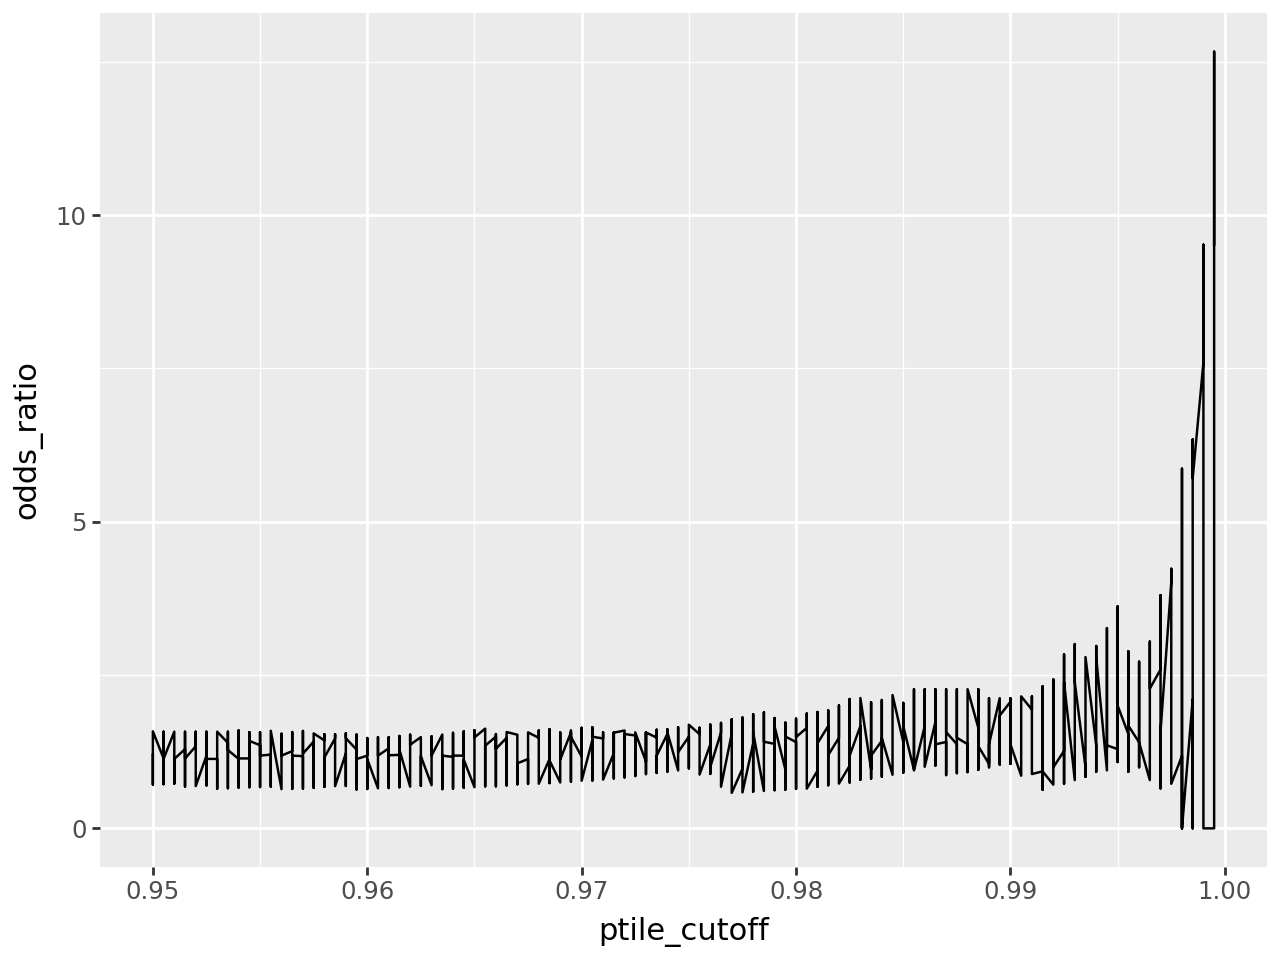

In [9]:
(
    ggplot(
        or_ptile,
        aes(x='ptile_cutoff', y='odds_ratio')
    )
    + geom_line()
)

## Resume code

In [9]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

n_steps = 100
# Create a lazy dataframe of cutoffs
cutoffs_lazy = pl.LazyFrame({
    # scale from or_threshold_anno to 1.0
    # "ptile_cutoff": [or_threshold_anno + (i/100)*(1-or_threshold_anno) for i in range(100)]
    "ptile_cutoff": [or_threshold_anno + (i/n_steps)*(1-or_threshold_anno) for i in range(n_steps)]
})

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "annotation_score_dircor_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .with_columns(
        above_cutoff = pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")
    )
    .group_by(["annotation", "region", "gene_name", "phenotype", "ptile_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_ptile") >= pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_ptile") < pl.col("ptile_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('ptile_cutoff')

or_df.write_parquet(f'/home/dnanexus/data_dir/odds_ratio_non_coding_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""pangolin_score""","""ENSG00000140443""","""IGF1R""","""arm_predicted_mass_right_int""",0.95,41,3272,743,73561,1.240593
"""absplice_dna_max""","""ENSG00000084674""","""APOB""","""aspartate_aminotransferase_int""",0.95,0,110,88,8263,0.0
"""gpn_star_llr_calibrated_mean""","""ENSG00000119403""","""PHF19""","""basal_metabolic_rate_int""",0.95,9,448,96,8823,1.846331
"""absplice2_max""","""ENSG00000127585""","""FBXL16""","""body_mass_index_bmi_int""",0.95,5,281,52,4896,1.675335
"""delta_score""","""ENSG00000084674""","""APOB""","""cholesterol_int""",0.95,6,352,100,8014,1.366023
…,…,…,…,…,…,…,…,…,…
"""mamphylop""","""ENSG00000116183""","""PAPPA2""","""whole_body_water_mass_int""",0.9995,1,42,784,79405,2.411474
"""verphylop""","""ENSG00000107863""","""ARHGAP21""","""whole_body_water_mass_int""",0.9995,0,13,318,29355,0.0
"""delta_score""","""ENSG00000182752""","""PAPPA""","""whole_body_water_mass_int""",0.9995,0,29,537,52585,0.0


## Plotting

In [10]:
or_df = pl.read_parquet(f'/home/dnanexus/data_dir/odds_ratio_non_coding_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')
or_df

annotation,region,gene_name,phenotype,ptile_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""pangolin_score""","""ENSG00000140443""","""IGF1R""","""arm_predicted_mass_right_int""",0.95,41,3272,743,73561,1.240593
"""absplice_dna_max""","""ENSG00000084674""","""APOB""","""aspartate_aminotransferase_int""",0.95,0,110,88,8263,0.0
"""gpn_star_llr_calibrated_mean""","""ENSG00000119403""","""PHF19""","""basal_metabolic_rate_int""",0.95,9,448,96,8823,1.846331
"""absplice2_max""","""ENSG00000127585""","""FBXL16""","""body_mass_index_bmi_int""",0.95,5,281,52,4896,1.675335
"""delta_score""","""ENSG00000084674""","""APOB""","""cholesterol_int""",0.95,6,352,100,8014,1.366023
…,…,…,…,…,…,…,…,…,…
"""mamphylop""","""ENSG00000116183""","""PAPPA2""","""whole_body_water_mass_int""",0.9995,1,42,784,79405,2.411474
"""verphylop""","""ENSG00000107863""","""ARHGAP21""","""whole_body_water_mass_int""",0.9995,0,13,318,29355,0.0
"""delta_score""","""ENSG00000182752""","""PAPPA""","""whole_body_water_mass_int""",0.9995,0,29,537,52585,0.0


In [11]:
or_df['ptile_cutoff'].n_unique()

100

In [12]:
plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['ptile_cutoff', 'annotation']),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['ptile_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['ptile_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['ptile_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'ptile_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('ptile_cutoff')
)
plt_df

annotation,ptile_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""absplice_dna_max""",0.95,1130,1.043238,1.202332,0.032713,1.26645,1.138215,"""#28a745""","""AbSplice (max)"""
"""absplice2_max""",0.95,1130,1.032005,1.139005,0.022253,1.182621,1.095388,"""#28a745""","""AbSplice2 (max)"""
"""gpn_score""",0.95,1176,1.110806,1.232138,0.020669,1.27265,1.191626,"""#942c80""","""GPN-MSA"""
"""gpn_star_llr_calibrated_mean""",0.95,1176,1.136328,1.208196,0.018458,1.244374,1.172018,"""#942c80""","""GPN-Star"""
"""mamphylop""",0.95,1176,1.07446,1.139299,0.020087,1.178669,1.099929,"""#942c80""","""Mammalian PhyloP"""
…,…,…,…,…,…,…,…,…,…
"""verphylop""",0.9995,1140,0.0,1.760702,0.279837,2.309182,1.212221,"""#942c80""","""Vertebrate PhyloP"""
"""absplice2_max""",0.9995,1087,0.0,5.609316,0.773891,7.126143,4.09249,"""#28a745""","""AbSplice2 (max)"""
"""gpn_star_llr_calibrated_mean""",0.9995,1159,0.0,3.261258,0.434827,4.113519,2.408997,"""#942c80""","""GPN-Star"""


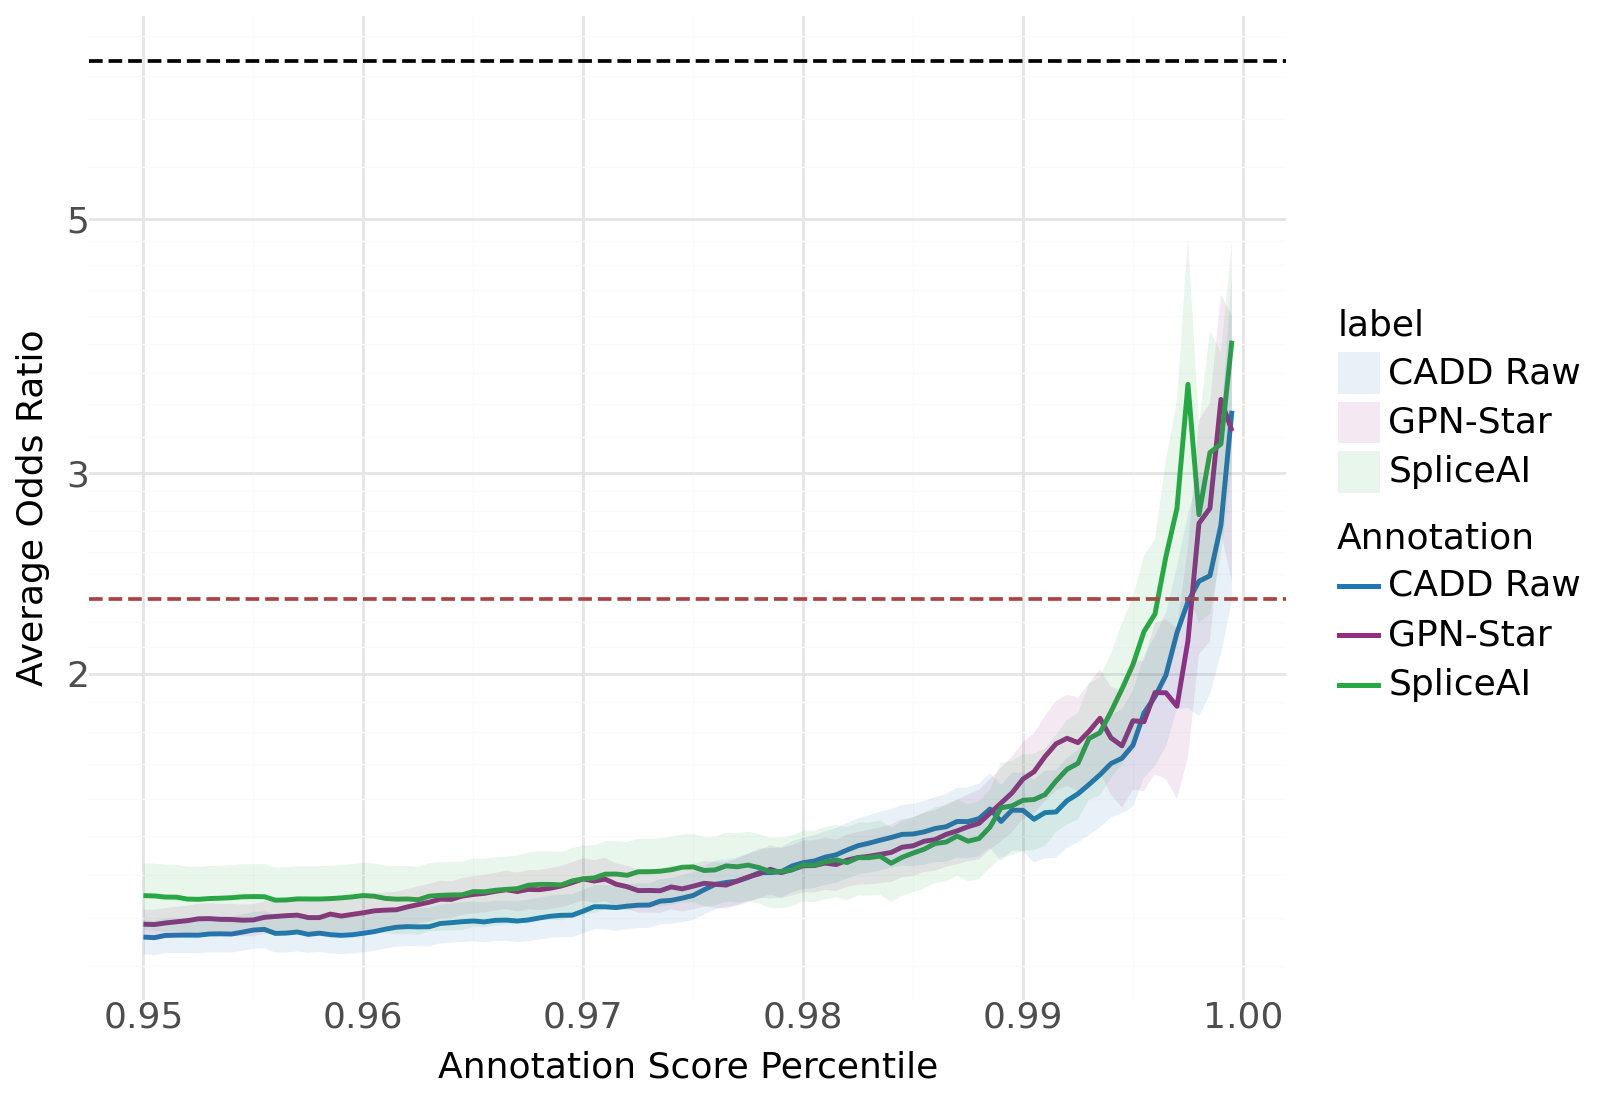

In [13]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))


am_lof_or_mean = {
    'loftee_all': 9.998645,
    'am_0.8_all': 3.628273,
    'loftee_coding': 6.874422,
    'am_0.8_coding': 2.323273
}

am_lof_or_median = {
    'loftee_all': 3.573782,
    'am_0.8_all': 2.027029,
    'loftee_coding': 3.04127,
    'am_0.8_coding': 1.770242
}

(
    ggplot(
        plt_df.filter(
            pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'delta_score'])
        ),
        aes(x='ptile_cutoff', y='avg_odds_ratio')
        # aes(x='ptile_cutoff', y='med_odds_ratio', color='label')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_hline(aes(yintercept=am_lof_or_mean['loftee_coding']), linetype='dashed', color='black', size=0.75)
    + geom_hline(aes(yintercept=am_lof_or_mean['am_0.8_coding']), linetype='dashed', color='#AA4344', size=0.75)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio",
        x="Annotation Score Percentile",
        color="Annotation",
    )
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        # legend_position = 'none',|
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [14]:
# find the first ptile_cutoff where avg_odds_ratio crosses the AM threshold
threshold = am_lof_or_mean['am_0.8_coding']
threshold = 2

crossing = (
    plt_df
    .select(['annotation', 'label', 'ptile_cutoff', 'avg_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .filter(pl.col('avg_odds_ratio') >= threshold)
    .sort(['label', 'ptile_cutoff'])
    .group_by('label')
    .agg([
        pl.first('annotation').alias('annotation'),
        pl.first('ptile_cutoff').alias('ptile_cross'),
        pl.first('avg_odds_ratio').alias('avg_or_at_cross'),
        pl.first('std_ci_upper').alias('std_ci_upper_at_cross'),
        pl.first('std_ci_lower').alias('std_ci_lower_at_cross'),
    ])
    .sort('ptile_cross', nulls_last=True)
)

print("threshold =", threshold)
crossing

threshold = 2


label,annotation,ptile_cross,avg_or_at_cross,std_ci_upper_at_cross,std_ci_lower_at_cross
str,str,f64,f64,f64,f64
"""Pangolin""","""pangolin_score""",0.9945,2.024419,2.289162,1.759676
"""AbSplice (max)""","""absplice_dna_max""",0.995,2.119471,2.431654,1.807287
"""SpliceAI""","""delta_score""",0.995,2.038059,2.337495,1.738624
"""AbSplice2 (max)""","""absplice2_max""",0.9955,2.149868,2.467042,1.832694
"""CADD Raw""","""cadd_raw""",0.997,2.173014,2.48259,1.863439
"""GPN-Star""","""gpn_star_llr_calibrated_mean""",0.9975,2.138413,2.586005,1.690821
"""GPN-MSA""","""gpn_score""",0.998,2.090618,2.524609,1.656626


In [15]:
# For each annotation in `crossing`, count unique ids in `melted_anno` with annotation_score_dircor_ptile > ptile_cross

cross_lf = crossing.select(['annotation', 'ptile_cross']).unique().lazy()

counts_df = (
    melted_anno.lazy()
    .join(cross_lf, on='annotation', how='inner')
    .filter(pl.col('annotation_score_dircor_ptile') > pl.col('ptile_cross'))
    .group_by(['annotation', 'ptile_cross'])
    .agg(
        n_ids_above = pl.col('id').n_unique()
    )
    .collect(engine='streaming')
    .sort('ptile_cross')
)

# Attach labels (if present) for easier interpretation
counts_df = counts_df.join(crossing.select(['annotation', 'label']).unique(), on='annotation', how='left')

counts_df = (
    counts_df
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
)
counts_df

annotation,ptile_cross,n_ids_above,label,color,label_right
str,f64,u64,str,str,str
"""pangolin_score""",0.9945,92746,"""Pangolin""","""#28a745""","""Pangolin"""
"""absplice_dna_max""",0.995,76351,"""AbSplice (max)""","""#28a745""","""AbSplice (max)"""
"""delta_score""",0.995,83595,"""SpliceAI""","""#28a745""","""SpliceAI"""
"""absplice2_max""",0.9955,75994,"""AbSplice2 (max)""","""#28a745""","""AbSplice2 (max)"""
"""cadd_raw""",0.997,62521,"""CADD Raw""","""#1f77b4""","""CADD Raw"""
"""gpn_star_llr_calibrated_mean""",0.9975,52163,"""GPN-Star""","""#942c80""","""GPN-Star"""
"""gpn_score""",0.998,41795,"""GPN-MSA""","""#942c80""","""GPN-MSA"""


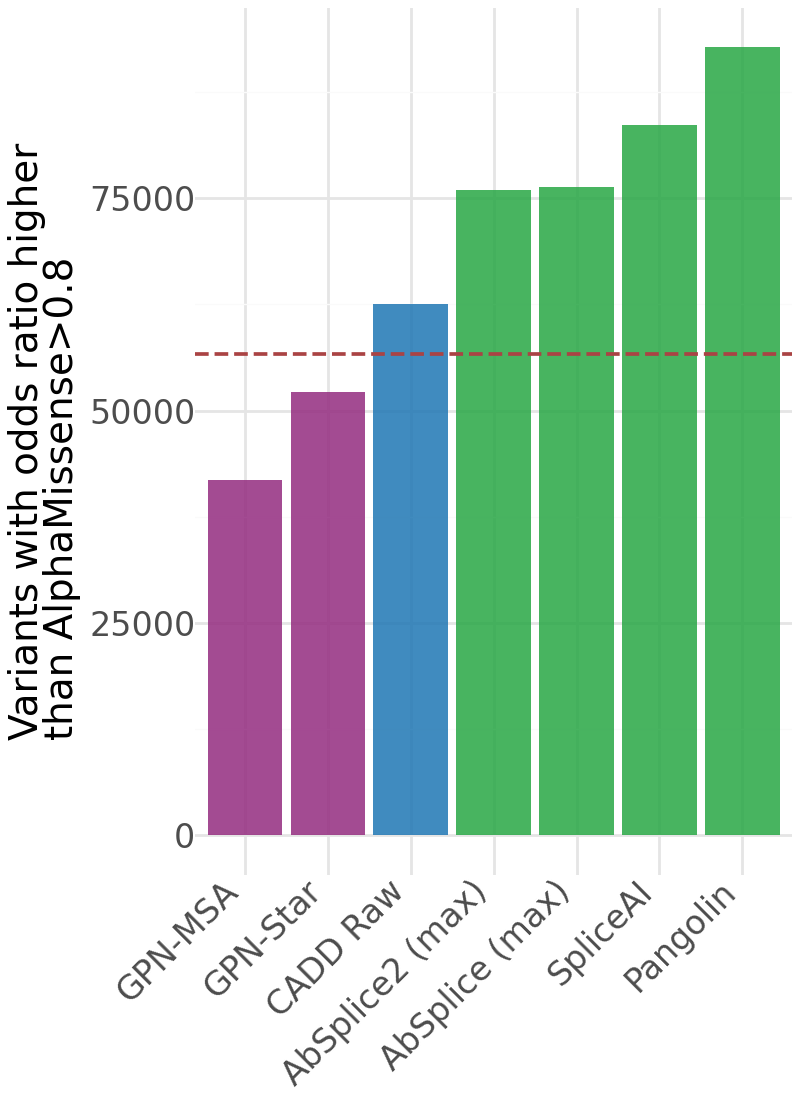

In [16]:
n_vars = {
    'loftee': 21519,
    'am_0.8_coding': 56609
}

plot_df = counts_df.to_pandas()
plot_df['label'] = pd.Categorical(
    plot_df['label'],
    categories=plot_df.sort_values('n_ids_above', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(plot_df['label'], plot_df['color']))

(
    ggplot(
        plot_df,
        aes(x='label', y='n_ids_above', fill='label')
    )
    + geom_bar(stat='identity', alpha=0.85)
    + geom_hline(aes(yintercept=n_vars['am_0.8_coding']), linetype='dashed', color='#AA4344', size=0.75)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        y="Variants with odds ratio higher\nthan AlphaMissense>0.8",
        x="",
    )
    # + scale_y_log10()
    + theme(
        figure_size=(4, 5.5),
        legend_position = 'none',
        axis_text_x=element_text(rotation=45, hjust=1),
        axis_text=element_text(size=12),
        axis_title=element_text(size=14),
        legend_text=element_text(size=12),
        legend_title=element_text(size=12),
    )
)